In [1]:
import pandas as pd 
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
def merge_dfs(dfs:list):
    for i in range(len(dfs)):
        if i==0:
            df=dfs[i]
        else:
            df = pd.merge(df, dfs[i], left_index=True, right_index=True)
    return df

def clean_process(df):
    df=df.where(df!=0,np.nan)                               # - Replace 0 with NaNs
    df=df.dropna()                                          # - Drop NaNs (preliminarily)
    df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
    df=df.interpolate('linear')                             # - Fill resulting NaNs with linear interpolation
    return df

def standardise(col):
    return (col - col.mean()) / col.std()

# Load, Process, Align Dates

In [3]:
folder=r'/Users/igorbykov/Desktop/Thesis/data'

# Get Brent data
name=r'commodities_data_v0.xlsx'
brent = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
brent.index = pd.to_datetime(brent.index) # - TTF Nat Gas Spot; USD (assumed)
brent = clean_process(brent)

# Get TTF data - EUR
name=r'ttf_front_month.xlsx'
ttf = pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,1],
    index_col=0
    )
ttf.index = pd.to_datetime(ttf.index) # - TTF Nat Gas Spot; USD (assumed)
ttf = clean_process(ttf)

# Load Utilities Equity Data - 'SX6P Index' is STOXX600 European Utilities; EUR
name=r'utilities_data_v0.xlsx'
utilities_equity=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,2],
    index_col=0
    )
utilities_equity.index = pd.to_datetime(utilities_equity.index)     # - Ensure datatime indexation
utilities_equity = clean_process(utilities_equity)

# Utility debt yield index data (10Y)
name=r'utilities_debt.xlsx'
util_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,3],
    index_col=0
    )/100                                                       # - Convert from percentage points to decimals  
util_yield_10y.index = pd.to_datetime(util_yield_10y.index)     # - Ensure datatime indexation
util_yield_10y = clean_process(util_yield_10y)

# Get EUR curve data (10Y)
name=r'euro_curve.xlsx'
govt_yield_10y=pd.read_excel(
    os.path.join(folder,name),
    usecols=[0,2],
    index_col=0
    )/100                                                       # - Convert from percentage points to decimals
govt_yield_10y.index = pd.to_datetime(govt_yield_10y.index)     # - Ensure datatime indexation
govt_yield_10y = clean_process(govt_yield_10y)

/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_28067/741284268.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_28067/741284268.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time axis is even
/var/folders/4_/ym5ph8gd12lfqnhrxz6p53rw0000gn/T/ipykernel_28067/741284268.py:12: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  df=df.resample('D', kind='timestamp', ).asfreq()        # - Make sure time ax

In [4]:
utilities_equity

,SX6P Index
Date,
2005-01-03,273.730000
2005-01-04,274.030000
2005-01-05,274.760000
2005-01-06,274.930000
2005-01-07,276.240000
...,...
2025-11-09,569.526667
2025-11-10,569.580000
2025-11-11,567.060000


# Duration Assumptions, Convert to Log-Returns, Combine

In [43]:
# Convert util yields to returns
# Utility duration will be higher than Govt duration 

D_util = 7.5
D_govt = 8.5

R_util_debt = np.log((1-D_util * util_yield_10y.diff()).dropna() )
R_govt = np.log((1-D_govt * govt_yield_10y.diff()).dropna() )

R_util_eqty = np.log((1+utilities_equity.diff() / utilities_equity.shift(1)).dropna() )
R_brent = np.log((1+brent.diff() / brent.shift(1)).dropna() )
R_ttf = np.log((1+ttf.diff() / ttf.shift(1)).dropna() )

df = merge_dfs([R_brent, R_ttf, R_util_eqty, R_util_debt, R_govt]).dropna()

# Resample frequency 
df = df.resample('3W').last()

print(df.head(5))

            CO1 Comdty  TTF_front_month  SX6P Index  IGEEUA10 BVLI Index  \
2011-05-01   -0.002045         0.000846    0.004123             0.000032   
2011-05-22   -0.006862         0.000831    0.001540             0.000672   
2011-06-12    0.000897        -0.001991    0.002870            -0.000185   
2011-07-03   -0.001135        -0.000161   -0.006307             0.000580   
2011-07-24   -0.002057        -0.000161   -0.001655             0.001481   

                 10Y  
2011-05-01  0.000582  
2011-05-22  0.000582  
2011-06-12 -0.000252  
2011-07-03  0.000823  
2011-07-24  0.000823  


# Regime Identification & Standardisation

In [44]:
mu_p_6m_brent = brent.rolling(window=180).mean().dropna()
std_p_6m_brent = brent.rolling(window=180).std().dropna()
threshold_brent = mu_p_6m_brent + 1.5*std_p_6m_brent

mu_p_6m_ttf = ttf.rolling(window=180).mean().dropna()
std_p_6m_ttf = ttf.rolling(window=180).std().dropna()
threshold_ttf = mu_p_6m_ttf + 1.5*std_p_6m_ttf

# threshold will be shorter than brent due to rolling calculation
indicator_brent=pd.Series(data=np.where(brent['CO1 Comdty'].loc[threshold_brent.index] > threshold_brent['CO1 Comdty'], 1, 0), index=threshold_brent.index)
indicator_ttf=pd.Series(data=np.where(ttf['TTF_front_month'].loc[threshold_ttf.index] > threshold_ttf['TTF_front_month'], 1, 0), index=threshold_ttf.index)


# crop indicator to fit into df
indicator_brent = indicator_brent[indicator_brent.index.isin(df.index)]
indicator_ttf = indicator_ttf[indicator_ttf.index.isin(df.index)]
df['D_brent']=indicator_brent
df['D_ttf']=indicator_ttf

df['govt_indic_brent'] = df['D_brent'] * df['10Y']
df['brent_indic_brent'] = df['D_brent'] * df['CO1 Comdty']

df['govt_indic_ttf'] = df['D_ttf'] * df['10Y']
df['brent_indic_ttf'] = df['D_ttf'] * df['TTF_front_month']

# Standardise all columns to make coefficients comparable
df=df.apply(lambda col: standardise(col), axis=0)

df['excess_R_util'] = df['IGEEUA10 BVLI Index'] - df['10Y']

# Target Definition Selection for regressions
# target = ['IGEEUA10 BVLI Index']
target = ['excess_R_util']

df.head(15)

,CO1 Comdty,TTF_front_month,SX6P Index,IGEEUA10 BVLI Index,10Y,D_brent,D_ttf,govt_indic_brent,brent_indic_brent,govt_indic_ttf,brent_indic_ttf,excess_R_util
2011-05-01,-0.104978,0.110942,1.092245,0.107500,1.007057,2.27479,-0.603450,2.970186,-0.693006,0.032223,-0.314686,-0.899557
2011-05-22,-0.627932,0.108373,0.394558,0.797907,1.007057,-0.43787,-0.603450,0.078124,0.091360,0.032223,-0.314686,-0.209150
2011-06-12,0.214426,-0.382682,0.753961,-0.127232,-0.442979,-0.43787,-0.603450,0.078124,0.091360,0.032223,-0.314686,0.315748
2011-07-03,-0.006193,-0.064214,-1.724769,0.698149,1.427472,-0.43787,-0.603450,0.078124,0.091360,0.032223,-0.314686,-0.729323
2011-07-24,-0.106254,-0.064309,-0.468316,1.671071,1.427472,-0.43787,-0.603450,0.078124,0.091360,0.032223,-0.314686,0.243599
2011-08-14,0.741434,0.957338,2.073563,0.134477,1.428552,-0.43787,1.650614,0.078124,0.091360,2.728638,1.520890,-1.294075
2011-09-04,-0.615182,-0.068066,-0.992778,2.360479,0.941494,-0.43787,1.650614,0.078124,0.091360,1.812106,-0.373437,1.418985
2011-09-25,0.106614,-0.068189,-3.243852,1.431291,0.941494,-0.43787,1.650614,0.078124,0.091360,1.812106,-0.373663,0.489797
2011-10-16,-1.338049,-0.263129,-0.096837,-0.529361,-0.753210,-0.43787,-0.603450,0.078124,0.091360,0.032223,-0.314686,0.223849
2011-11-06,0.944619,-0.418858,-0.620064,1.115993,-2.484747,-0.43787,-0.603450,0.078124,0.091360,0.032223,-0.314686,3.600740


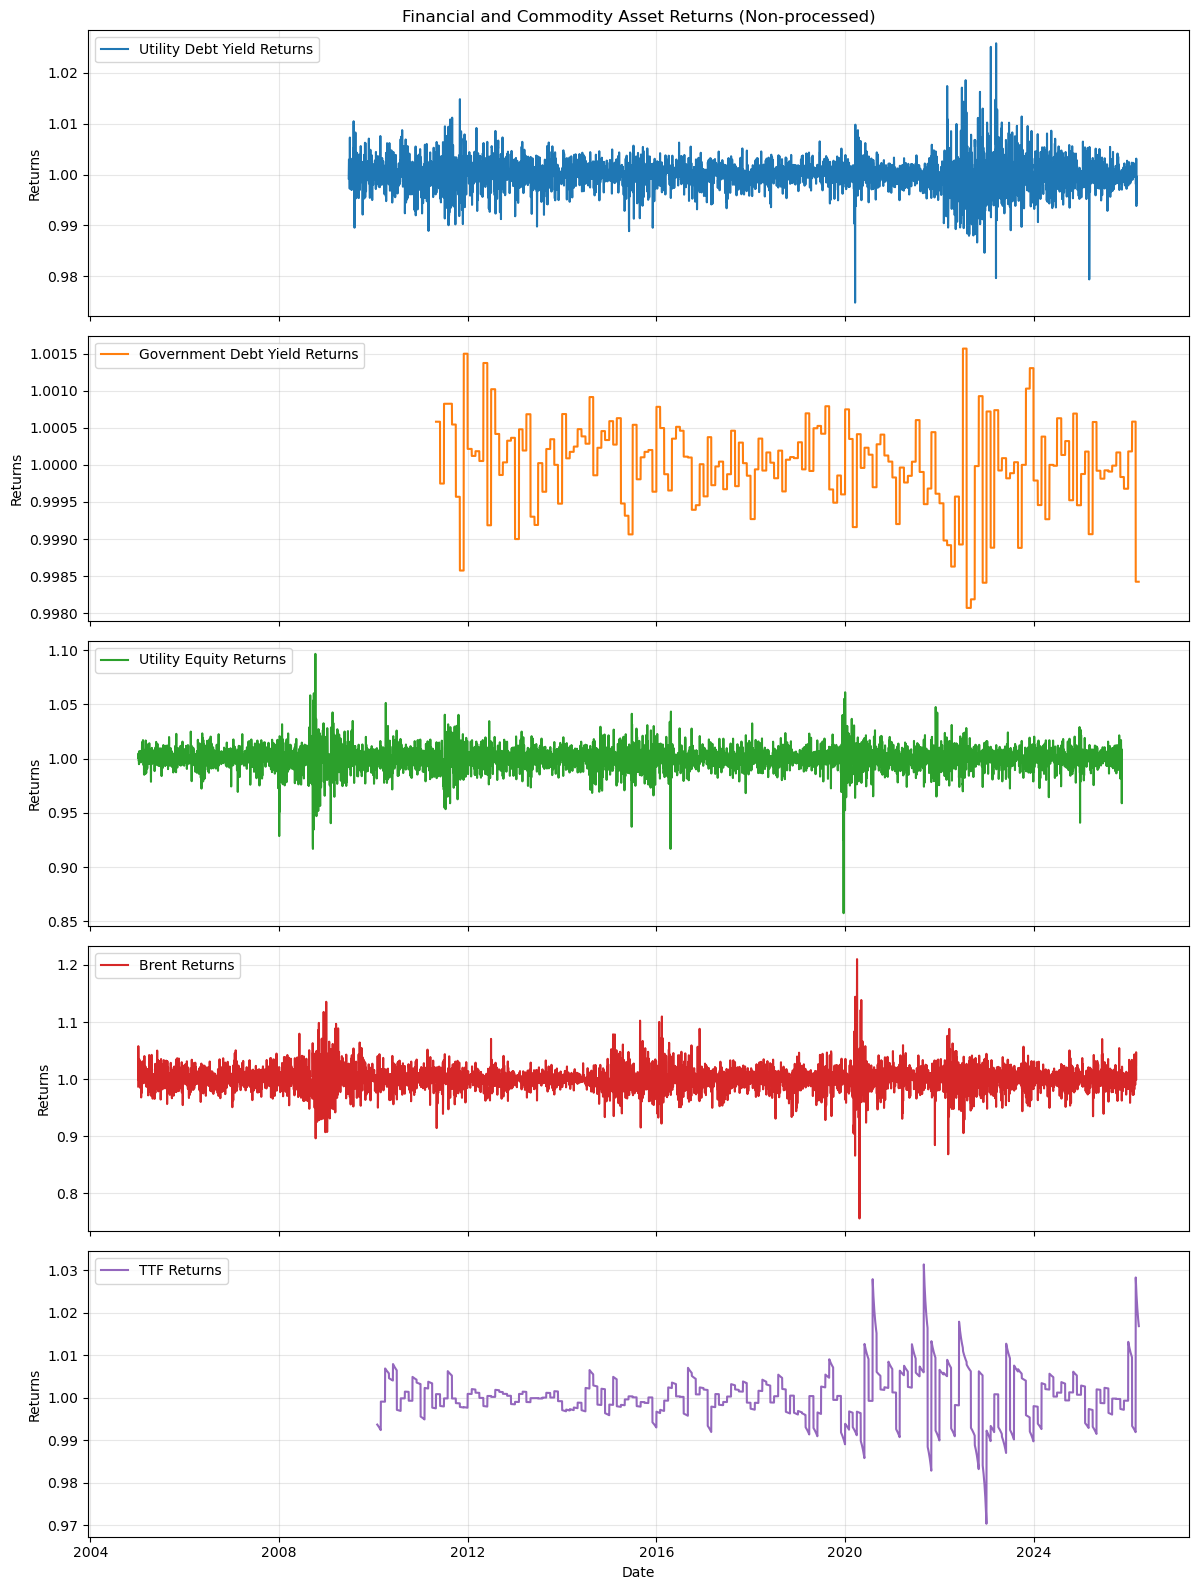

In [45]:
series_to_plot = {
    'Utility Debt Yield Returns': (1 - D_util * util_yield_10y.diff()).dropna(),
    'Government Debt Yield Returns': (1 - D_govt * govt_yield_10y.diff()).dropna(),
    'Utility Equity Returns': (1 + utilities_equity.pct_change()).dropna(),
    'Brent Returns': (1 + brent.pct_change()).dropna(),
    'TTF Returns': (1 + ttf.pct_change()).dropna()
}

fig, axes = plt.subplots(nrows=len(series_to_plot), ncols=1, figsize=(12, 16), sharex=True)

for i, (label, data) in enumerate(series_to_plot.items()):
    axes[i].plot(data, label=label, color=f'C{i}') # C0, C1, etc. gives distinct colors
    axes[i].set_ylabel('Returns')
    axes[i].legend(loc='upper left')
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Financial and Commodity Asset Returns (Non-processed)')
plt.xlabel('Date')
plt.tight_layout() # Prevents labels from overlapping
plt.show()

# Baseline Unconditional Hedge Model

In [46]:
unconditional_model_brent = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y','CO1 Comdty', 'SX6P Index']]
        )
        ).fit(cov_type='HC3')

print(unconditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.415
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     30.00
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.33e-16
Time:                        17:31:55   Log-Likelihood:                -354.51
No. Observations:                 254   AIC:                             717.0
Df Residuals:                     250   BIC:                             731.2
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.735e-18      0.064    2.7e-17      1.0

In [47]:
unconditional_model_ttf = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y','TTF_front_month', 'SX6P Index']]
        )
        ).fit(cov_type='HC3')
print(unconditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.417
Model:                            OLS   Adj. R-squared:                  0.410
Method:                 Least Squares   F-statistic:                     30.99
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           4.55e-17
Time:                        17:31:55   Log-Likelihood:                -354.26
No. Observations:                 254   AIC:                             716.5
Df Residuals:                     250   BIC:                             730.7
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.735e-18      0.063   2.

# Conditional Hedge Model

In [48]:
conditional_model_brent = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y', 'govt_indic_brent', 'CO1 Comdty', 'brent_indic_brent', 'D_brent', 'SX6P Index']]
        ),
        ).fit(cov_type='HC3')
print(conditional_model_brent.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.416
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     17.54
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           6.69e-17
Time:                        17:31:56   Log-Likelihood:                -354.31
No. Observations:                 254   AIC:                             722.6
Df Residuals:                     247   BIC:                             747.4
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              1.735e-18      0.06

In [49]:
conditional_model_ttf = sm.OLS(
    df[target],
    sm.add_constant(
        df[['10Y', 'govt_indic_ttf', 'TTF_front_month', 'brent_indic_ttf', 'D_ttf', 'SX6P Index']]
        ),
        ).fit(cov_type='HC3')
print(conditional_model_ttf.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_R_util   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     18.97
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.81e-18
Time:                        17:31:56   Log-Likelihood:                -353.18
No. Observations:                 254   AIC:                             720.4
Df Residuals:                     247   BIC:                             745.1
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.735e-18      0.064   2.

# Hedge Effectiveness

In [50]:
HE_unconditional_brent = unconditional_model_brent.rsquared
HE_conditional_brent = conditional_model_brent.rsquared

print(f"Brent: Unconditional HE: {HE_unconditional_brent:.4f}")
print(f"Brent: Conditional HE: {HE_conditional_brent:.4f}")

Brent: Unconditional HE: 0.4154
Brent: Conditional HE: 0.4163


In [51]:
HE_unconditional_ttf = unconditional_model_ttf.rsquared
HE_conditional_ttf = conditional_model_ttf.rsquared

print(f"TTF: Unconditional HE: {HE_unconditional_ttf:.4f}")
print(f"TTF: Conditional HE: {HE_conditional_ttf:.4f}")

TTF: Unconditional HE: 0.4166
TTF: Conditional HE: 0.4215
